In [ ]:
#  AI and Social Media Analysis to Detect Fake News 
# Author: Muhammad Humayun Khan

import pandas as pd

# Paths to the files
fake_path = "../datasets/fake_news_detection/politifact_fake.csv"
real_path = "../datasets/fake_news_detection/politifact_real.csv"

# Load CSV files
df_fake = pd.read_csv(fake_path)
df_real = pd.read_csv(real_path)

# Add labels: 1 for fake, 0 for real
df_fake['label'] = 1
df_real['label'] = 0

# Combine both datasets
df = pd.concat([df_fake, df_real], ignore_index=True)

# Shuffle the combined DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display shape and first few rows
print(f"Dataset shape: {df.shape}")
print(df.head())

# the dataset having columns such as id(not needed), news_url(not needed), title(using for fake news classification),
# tweet_ids(not needed), label(requiring for the training)


Dataset shape: (1056, 5)
                id                                           news_url  \
0  politifact14885  www.breakingnews247.net/59bc13819a723/world-s-...   
1   politifact1106  http://frwebgate.access.gpo.gov/cgi-bin/getdoc...   
2   politifact1678  http://abcnews.go.com/ThisWeek/video/supreme-c...   
3    politifact370  http://tonto.eia.doe.gov/dnav/pet/pet_move_wkl...   
4  politifact15263  http://sciencevibe.com/2018/04/11/dying-78-yea...   

                                               title  \
0  World's most popular candy to be removed from ...   
1                         Browse Congressional Bills   
2                        Supreme Court Vacancy Video   
3                             U.S. Imports & Exports   
4  Dying 78 Year Old CIA Agent Admits To Killing ...   

                                           tweet_ids  label  
0  908193166632812545\t908318679821160450\t908327...      1  
1  2761266599\t3283658037\t3439787429\t5180526172...      0  
2            

In [5]:
# save the combined dataset
df.to_csv("../datasets/fake_news_detection/combined_politifact.csv", index=False)


In [6]:
# let's clean the dataset
# Keep only the columns we need
df = df[['title', 'label']]

# Drop rows with missing or empty titles
df.dropna(subset=['title'], inplace=True)
df = df[df['title'].str.strip() != '']

print(f"Cleaned dataset shape: {df.shape}")
print(df.head())


Cleaned dataset shape: (1056, 2)
                                               title  label
0  World's most popular candy to be removed from ...      1
1                         Browse Congressional Bills      0
2                        Supreme Court Vacancy Video      0
3                             U.S. Imports & Exports      0
4  Dying 78 Year Old CIA Agent Admits To Killing ...      1


C:\Users\Just Bring\AppData\Local\Temp\ipykernel_4136\1654322771.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['title'], inplace=True)


In [7]:
# Text Processing pipeline now in the NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# Apply preprocessing
df['clean_title'] = df['title'].apply(preprocess)

# Preview
df[['title', 'clean_title', 'label']].head()


,title,clean_title,label
0,World's most popular candy to be removed from ...,world popular candy removed shelf october,1
1,Browse Congressional Bills,browse congressional bill,0
2,Supreme Court Vacancy Video,supreme court vacancy video,0
3,U.S. Imports & Exports,u import export,0
4,Dying 78 Year Old CIA Agent Admits To Killing ...,dying year old cia agent admits killing marily...,1


In [8]:
# convert text to Vector (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_title'])  # input features
y = df['label']  # target


In [9]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# train a logistic regression model first - ML based approach
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))




Accuracy: 0.7122641509433962
              precision    recall  f1-score   support

           0       0.68      0.96      0.79       122
           1       0.87      0.38      0.53        90

    accuracy                           0.71       212
   macro avg       0.77      0.67      0.66       212
weighted avg       0.76      0.71      0.68       212



In [ ]:
# prediction/evaluate the model on the new news
def predict_fake_news(headline):
    clean_text = preprocess(headline)
    vec = vectorizer.transform([clean_text])  # transform to TF-IDF
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0][pred]
    label = "FAKE" if pred == 1 else "REAL"
    print(f"Prediction: {label} (Confidence: {proba:.2f})")

predict_fake_news("Breaking: Joe Biden signs major climate bill into law")
predict_fake_news("Dying CIA agent confesses to killing Marilyn Monroe")
predict_fake_news("NASA confirms alien spacecraft found on moon")

# the model will predict the confidence meaning that probability either news is real or fake
# just like in the below output 0.55 → 55% confident the news is real
# for all the news the model isn't confident enough to say it's fake or real as values are almost above 50% and not that in the range of 80 to 100%
# so ML based approach struggling in detecting the model fake news detection



Prediction: REAL (Confidence: 0.55)
Prediction: FAKE (Confidence: 0.58)
Prediction: FAKE (Confidence: 0.63)


In [13]:
# let's try the deep leanring approach
# first tokenization and padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
MAX_VOCAB = 5000
MAX_LEN = 25  # Short titles, so small padding is enough

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_title'])

X_seq = tokenizer.texts_to_sequences(df['clean_title'])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post')


In [14]:
# encode labels
import numpy as np

y = np.array(df['label'])  # Already binary: 0 = real, 1 = fake


In [15]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)


In [17]:
# define and train the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()
model.add(Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

model.summary()


Epoch 1/5


d:\Drive I\Work\Summer 2025 Personal Growth\natural_language_processing\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.5647 - loss: 0.6847 - val_accuracy: 0.5755 - val_loss: 0.6798
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5975 - loss: 0.6662 - val_accuracy: 0.5991 - val_loss: 0.6118
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8523 - loss: 0.4131 - val_accuracy: 0.7972 - val_loss: 0.7054
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9411 - loss: 0.2113 - val_accuracy: 0.7736 - val_loss: 0.8050
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9500 - loss: 0.1785 - val_accuracy: 0.7736 - val_loss: 0.7145


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,269 (4.04 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 706,180 (2.69 MB)

In [18]:
# evaluate the model
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7629 - loss: 0.7738

Test Accuracy: 0.77


In [23]:
# predict custom headlines


def predict_lstm(headline):
    clean = preprocess(headline)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = model.predict(pad)[0][0]

    label = "FAKE" if prob >= 0.5 else "REAL"
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f"Prediction: {label} (Confidence: {confidence:.2f})")



In [24]:
# Examples headings
predict_lstm("Biden signs historic healthcare bill into law")
predict_lstm("NASA finds aliens under Antarctica ice")
predict_lstm("Elon Musk confirms colonizing Mars by 2026")
predict_lstm("Government releases tax relief package for small businesses")

# the LSTM performs better because
# Captures sequence relationships between words (context-aware)
# Learns patterns in word order, not just word frequency
# Handles short, noisy text like headlines better


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Prediction: FAKE (Confidence: 0.88)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: FAKE (Confidence: 0.91)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Prediction: FAKE (Confidence: 0.90)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prediction: REAL (Confidence: 0.99)


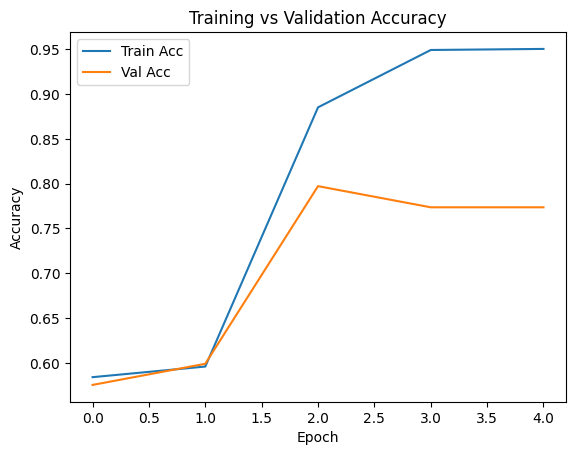

In [22]:
# visualize training history
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()
